# Fault Tree Analysis of Smart Infusion Pump Cybersecurity-Safety Failure

This notebook performs Fault Tree Analysis for a smart infusion pump.

The top event is:

**Unsafe medication delivery**

The model includes:

- Cybersecurity failures
- Incorrect dose command failures
- Detection and alarm failures
- Pump hardware failures

The notebook uses both:

1. The `pfta` library model definition
2. A custom Python FTA analysis engine

In [1]:
# Install required Python libraries
!pip install pfta graphviz pandas

# Install system Graphviz package for diagram rendering in Colab
!apt-get install -y graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.1 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


##  Import Required Libraries

This block imports all libraries needed for the analysis.

- `pfta` creates the library-based fault tree model.
- `dataclass` creates simple node structures.
- `field` creates empty child lists safely.
- `product` helps combine cut sets.
- `pandas` creates tables.
- `graphviz` draws the fault tree.
- `IPython.display` displays images and tables in Colab.

In [2]:
# Import PFTA FaultTree class
from pfta.core import FaultTree as PFTATree

# Import dataclass tools for creating simple node structures
from dataclasses import dataclass, field

# Import product for cut set combinations
from itertools import product

# Import pandas for tables
import pandas as pd

# Import Graphviz for fault tree visualization
from graphviz import Digraph

# Import display tools for Jupyter Notebook / Google Colab
from IPython.display import Image, display

##  Define the Fault Tree Using PFTA Text Format

This block defines the fault tree using the PFTA library format.

The basic events are A to K.

The gates are G1 to G6 and TOP.

The top event is:

**Unsafe medication delivery**

In [3]:
# Define the fault tree in PFTA text format
fta_text = """
- time_unit: hour
- times: 1

Event: A
- label: Unauthorized dose parameter change
- model_type: Fixed
- probability: 0.018
- intensity: 0

Event: B
- label: Wireless command spoofing
- model_type: Fixed
- probability: 0.015
- intensity: 0

Event: C
- label: Incorrect dose command issued
- model_type: Fixed
- probability: 0.02
- intensity: 0

Event: D
- label: Alert suppression attack
- model_type: Fixed
- probability: 0.012
- intensity: 0

Event: E
- label: Flow sensor calibration error
- model_type: Fixed
- probability: 0.025
- intensity: 0

Event: F
- label: Unsafe delivery not detected
- model_type: Fixed
- probability: 0.018
- intensity: 0

Event: G
- label: Overdose path active
- model_type: Fixed
- probability: 0.02
- intensity: 0

Event: H
- label: Pump motor fault
- model_type: Fixed
- probability: 0.03
- intensity: 0

Event: I
- label: Tubing blockage
- model_type: Fixed
- probability: 0.035
- intensity: 0

Event: J
- label: Battery failure
- model_type: Fixed
- probability: 0.022
- intensity: 0

Event: K
- label: Pump unavailable or faulty
- model_type: Fixed
- probability: 0.026
- intensity: 0

Gate: G1
- label: Malicious dose manipulation
- type: OR
- inputs: A, B

Gate: G2
- label: Wrong dose command created
- type: AND
- inputs: G1, C

Gate: G3
- label: Detection and alarm failure
- type: OR
- inputs: D, E, F

Gate: G4
- label: Undetected overdose condition
- type: AND
- inputs: G2, G3, G

Gate: G5
- label: Pump hardware delivery failure
- type: OR
- inputs: H, I, J

Gate: G6
- label: Pump unavailable condition
- type: AND
- inputs: G5, K

Gate: TOP
- label: Unsafe medication delivery
- type: OR
- inputs: G4, G6
"""

# Create PFTA model from the text
pfta_model = PFTATree(fta_text)

# Confirm model creation
print("PFTA model created successfully.")

PFTA model created successfully.


##  Create the Node Class

This block creates a simple `Node` class.

Each node can represent:

- A basic event
- A logic gate

Each node stores:

- Name
- Type
- Probability
- Children

In [4]:
# Create a node class for basic events and gates
@dataclass
class Node:

    # Name of event or gate
    name: str

    # Type of node: BASIC, OR, AND, XOR, PAND, or INHIBIT
    kind: str

    # Probability for basic events
    p: float = None

    # Child nodes for gates
    children: list = field(default_factory=list)

##  Helper Functions

This block defines helper functions used by the custom FTA engine.

The helper functions:

- Format probability values
- Calculate gate probabilities
- Multiply values
- Remove non-minimal cut sets

In [5]:
# Format probability values neatly
def fmt(x):

    # Keep five decimal places and remove unnecessary zeros
    return f"{x:.5f}".rstrip("0").rstrip(".")


# Helper function to multiply values
def product_value(values):

    # Start multiplication from 1
    r = 1

    # Multiply each value
    for v in values:
        r *= v

    # Return product
    return r


# Calculate gate output probability
def gate(kind, ps):

    # AND, PAND, and INHIBIT gates are treated as multiplication in this simple model
    if kind in ["AND", "PAND", "INHIBIT"]:

        # Start with 1 for multiplication
        r = 1

        # Multiply each input probability
        for p in ps:
            r *= p

        # Return final AND/PAND/INHIBIT result
        return r

    # OR gate probability calculation
    if kind == "OR":

        # Start with 1 for multiplication of complements
        r = 1

        # Multiply probability that each input does not occur
        for p in ps:
            r *= (1 - p)

        # Return probability that at least one input occurs
        return 1 - r

    # XOR means exactly one input occurs
    if kind == "XOR":

        # Calculate probability that only one input occurs
        return sum(
            p * product_value(1 - q for j, q in enumerate(ps) if j != i)
            for i, p in enumerate(ps)
        )

    # Raise error for unsupported gate type
    raise ValueError("Unsupported gate type")


# Remove non-minimal cut sets
def minimize(cutsets):

    # Remove duplicate cut sets and sort by size
    unique = sorted(
        set(frozenset(c) for c in cutsets),
        key=lambda x: (len(x), sorted(x))
    )

    # Store only minimal cut sets
    minimal = []

    # Check every cut set
    for c in unique:

        # Keep cut set only if no smaller cut set already covers it
        if not any(m.issubset(c) for m in minimal):
            minimal.append(c)

    # Convert frozensets back to normal sets
    return [set(c) for c in minimal]

## Create the Custom FTA Class

This class performs the main fault tree analysis.

It can:

1. Evaluate probabilities
2. Collect all nodes
3. Create a probability table
4. Create a gate-by-gate analysis table
5. Generate minimal cut sets
6. Draw the fault tree diagram

In [6]:
# Fault Tree Analysis class
class FTA:

    # Store the top event
    def __init__(self, top):
        self.top = top

    # Evaluate all node probabilities
    def evaluate(self):

        # Store probabilities for all nodes
        probs = {}

        # Recursive solver function
        def solve(n):

            # If node is a basic event, return its probability directly
            if n.kind == "BASIC":
                probs[n.name] = n.p
                return n.p

            # Evaluate all child node probabilities
            child_probs = [solve(c) for c in n.children]

            # Calculate current gate probability
            probs[n.name] = gate(n.kind, child_probs)

            # Return current node probability
            return probs[n.name]

        # Start solving from the top event
        return solve(self.top), probs

    # Collect all nodes in the fault tree
    def nodes(self):

        # Store nodes here
        out = []

        # Recursive function to walk through tree
        def walk(n):

            # Add current node
            out.append(n)

            # Visit all child nodes
            for c in n.children:
                walk(c)

        # Start walking from top event
        walk(self.top)

        # Return all collected nodes
        return out

    # Create gate-by-gate analysis table
    def gate_analysis(self):

        # Evaluate probabilities first
        _, probs = self.evaluate()

        # Store table rows
        rows = []

        # Check every node
        for n in self.nodes():

            # Include only gate nodes
            if n.kind != "BASIC":

                # Add gate information to table
                rows.append({
                    "Gate": n.name,
                    "Type": n.kind,
                    "Inputs": " | ".join(c.name for c in n.children),
                    "Input Probabilities": " | ".join(fmt(probs[c.name]) for c in n.children),
                    "Output": fmt(probs[n.name])
                })

        # Return gate analysis table
        return pd.DataFrame(rows)

    # Create probability table
    def probability_table(self):

        # Evaluate probabilities first
        _, probs = self.evaluate()

        # Return probability table for all nodes
        return pd.DataFrame([
            {
                "Node": n.name,
                "Type": n.kind,
                "Probability": fmt(probs[n.name])
            }
            for n in self.nodes()
        ])

    # Generate minimal cut sets
    def cutsets(self, n=None):

        # Start from top event if no node is provided
        n = n or self.top

        # Basic event is its own cut set
        if n.kind == "BASIC":
            return [{n.name}]

        # Get cut sets from child nodes
        child_sets = [self.cutsets(c) for c in n.children]

        # OR and XOR gates pass through child cut sets
        if n.kind in ["OR", "XOR"]:
            return minimize([cs for group in child_sets for cs in group])

        # AND, PAND, and INHIBIT gates combine child cut sets
        if n.kind in ["AND", "PAND", "INHIBIT"]:
            return minimize([
                set().union(*combo)
                for combo in product(*child_sets)
            ])

    # Convert cut sets into a table
    def cutset_table(self, sets):

        # Return cut set table
        return pd.DataFrame([
            {
                "ID": f"MCS-{i}",
                "Cut Set": " + ".join(sorted(s)),
                "Order": len(s)
            }
            for i, s in enumerate(sets, 1)
        ])

    # Draw the fault tree
    def draw(self, file="smart_infusion_pump_fta"):

        # Create Graphviz directed graph
        dot = Digraph(format="png")

        # Set top-to-bottom layout
        dot.attr(rankdir="TB", splines="ortho")

        # Recursive function to add nodes
        def add(n):

            # Basic events show probability; gates show gate type
            label = f"{n.name}\nP={fmt(n.p)}" if n.kind == "BASIC" else f"{n.name}\n[{n.kind}]"

            # Basic events are boxes; gates are ellipses
            shape = "box" if n.kind == "BASIC" else "ellipse"

            # Add node to Graphviz diagram
            dot.node(n.name, label, shape=shape)

            # Add child nodes and edges
            for c in n.children:

                # Recursively add child node
                add(c)

                # Connect parent to child
                dot.edge(n.name, c.name, arrowhead="none")

        # Start drawing from the top event
        add(self.top)

        # Render graph to PNG file
        path = dot.render(file, cleanup=True)

        # Display graph in notebook
        display(Image(filename=path))

## Build the Smart Infusion Pump Case Study

This block manually builds the same smart infusion pump fault tree for the custom engine.

The basic events describe:

- Cyber attacks
- Wrong command creation
- Detection failure
- Hardware faults
- Pump unavailability

The top event is:

**Unsafe medication delivery**

In [7]:
# Cybersecurity-related event: attacker changes dose setting
A = Node("Unauthorized dose parameter change", "BASIC", 0.018)

# Cybersecurity-related event: attacker sends wireless spoofed command
B = Node("Wireless command spoofing", "BASIC", 0.015)

# Incorrect dose command event
C = Node("Incorrect dose command issued", "BASIC", 0.02)

# Cybersecurity-related alert failure
D = Node("Alert suppression attack", "BASIC", 0.012)

# Technical sensor issue
E = Node("Flow sensor calibration error", "BASIC", 0.025)

# Detection failure event
F = Node("Unsafe delivery not detected", "BASIC", 0.018)

# Overdose path condition
G = Node("Overdose path active", "BASIC", 0.02)

# Hardware fault
H = Node("Pump motor fault", "BASIC", 0.03)

# Physical delivery blockage
I = Node("Tubing blockage", "BASIC", 0.035)

# Power-related failure
J = Node("Battery failure", "BASIC", 0.022)

# General pump unavailability
K = Node("Pump unavailable or faulty", "BASIC", 0.026)


# Gate G1: malicious dose manipulation occurs if A OR B occurs
G1 = Node("Malicious dose manipulation", "OR", children=[A, B])

# Gate G2: wrong dose command occurs if G1 AND C occur
G2 = Node("Wrong dose command created", "AND", children=[G1, C])

# Gate G3: detection and alarm failure occurs if D OR E OR F occurs
G3 = Node("Detection and alarm failure", "OR", children=[D, E, F])

# Gate G4: undetected overdose condition occurs if G2 AND G3 AND G occur
G4 = Node("Undetected overdose condition", "AND", children=[G2, G3, G])

# Gate G5: pump hardware delivery failure occurs if H OR I OR J occurs
G5 = Node("Pump hardware delivery failure", "OR", children=[H, I, J])

# Gate G6: pump unavailable condition occurs if G5 AND K occur
G6 = Node("Pump unavailable condition", "AND", children=[G5, K])

# Top event occurs if G4 OR G6 occurs
TOP = Node(
    "Unsafe medication delivery",
    "OR",
    children=[G4, G6]
)

##  Run the Fault Tree Analysis

This block runs the final analysis.

It outputs:

- Top event probability
- Fault tree diagram
- Probability table
- Gate-by-gate analysis
- MOCUS minimal cut sets
- MICSUP minimal cut sets

In this simplified notebook, MOCUS and MICSUP use the same cut set function, so the results should match.

SMART INFUSION PUMP CYBERSECURITY-SAFETY FTA
Top Event Probability: 0.0022


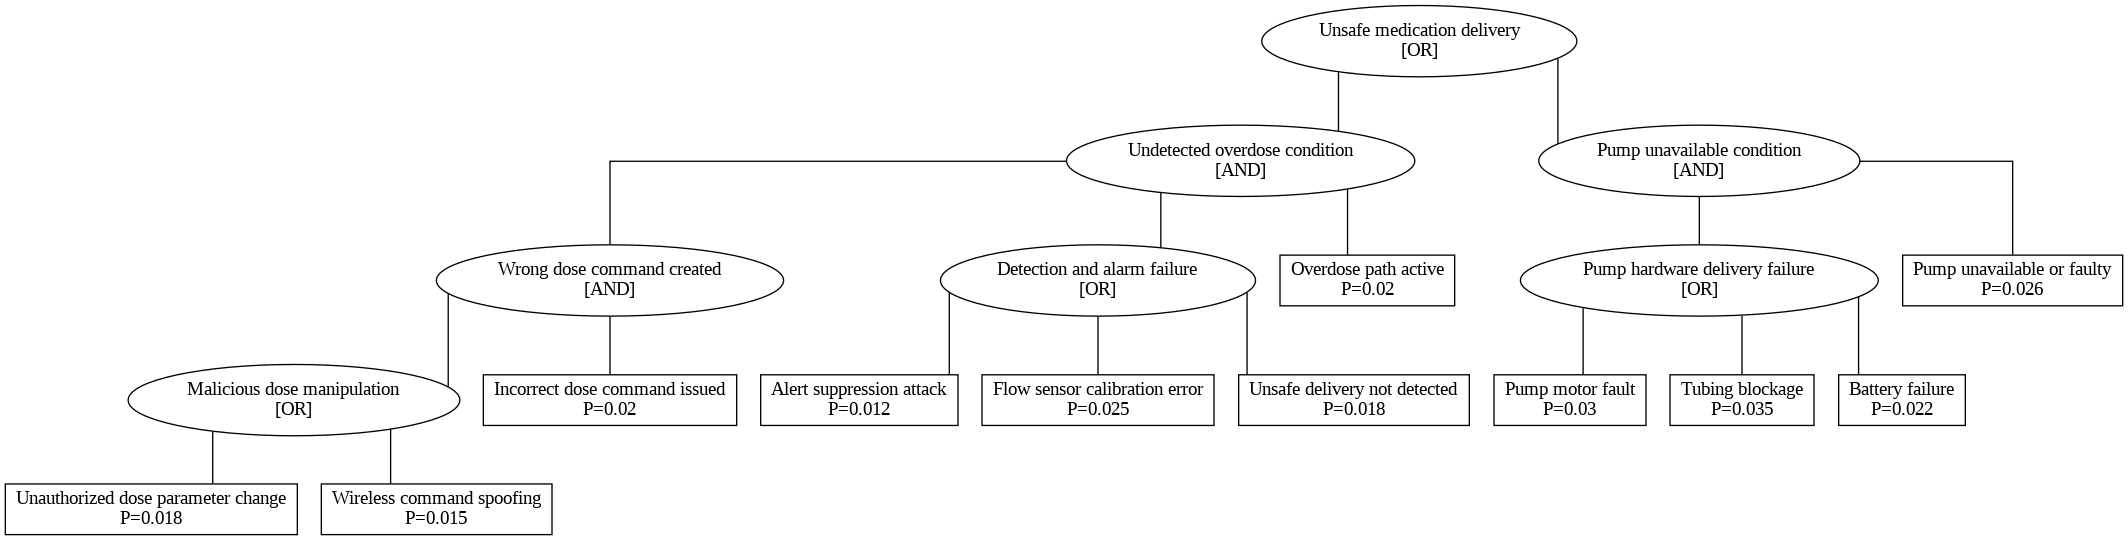


1. Probability Table


,Node,Type,Probability
0,Unsafe medication delivery,OR,0.0022
1,Undetected overdose condition,AND,0
2,Wrong dose command created,AND,0.00065
3,Malicious dose manipulation,OR,0.03273
4,Unauthorized dose parameter change,BASIC,0.018
5,Wireless command spoofing,BASIC,0.015
6,Incorrect dose command issued,BASIC,0.02
7,Detection and alarm failure,OR,0.05404
8,Alert suppression attack,BASIC,0.012
9,Flow sensor calibration error,BASIC,0.025



2. Gate-by-Gate Analysis


,Gate,Type,Inputs,Input Probabilities,Output
0,Unsafe medication delivery,OR,Undetected overdose condition | Pump unavailab...,0 | 0.0022,0.0022
1,Undetected overdose condition,AND,Wrong dose command created | Detection and ala...,0.00065 | 0.05404 | 0.02,0
2,Wrong dose command created,AND,Malicious dose manipulation | Incorrect dose c...,0.03273 | 0.02,0.00065
3,Malicious dose manipulation,OR,Unauthorized dose parameter change | Wireless ...,0.018 | 0.015,0.03273
4,Detection and alarm failure,OR,Alert suppression attack | Flow sensor calibra...,0.012 | 0.025 | 0.018,0.05404
5,Pump unavailable condition,AND,Pump hardware delivery failure | Pump unavaila...,0.08454 | 0.026,0.0022
6,Pump hardware delivery failure,OR,Pump motor fault | Tubing blockage | Battery f...,0.03 | 0.035 | 0.022,0.08454



3. MOCUS Minimal Cut Sets


,ID,Cut Set,Order
0,MCS-1,Battery failure + Pump unavailable or faulty,2
1,MCS-2,Pump motor fault + Pump unavailable or faulty,2
2,MCS-3,Pump unavailable or faulty + Tubing blockage,2
3,MCS-4,Alert suppression attack + Incorrect dose comm...,4
4,MCS-5,Alert suppression attack + Incorrect dose comm...,4
5,MCS-6,Flow sensor calibration error + Incorrect dose...,4
6,MCS-7,Flow sensor calibration error + Incorrect dose...,4
7,MCS-8,Incorrect dose command issued + Overdose path ...,4
8,MCS-9,Incorrect dose command issued + Overdose path ...,4



4. MICSUP Minimal Cut Sets


,ID,Cut Set,Order
0,MCS-1,Battery failure + Pump unavailable or faulty,2
1,MCS-2,Pump motor fault + Pump unavailable or faulty,2
2,MCS-3,Pump unavailable or faulty + Tubing blockage,2
3,MCS-4,Alert suppression attack + Incorrect dose comm...,4
4,MCS-5,Alert suppression attack + Incorrect dose comm...,4
5,MCS-6,Flow sensor calibration error + Incorrect dose...,4
6,MCS-7,Flow sensor calibration error + Incorrect dose...,4
7,MCS-8,Incorrect dose command issued + Overdose path ...,4
8,MCS-9,Incorrect dose command issued + Overdose path ...,4



MOCUS and MICSUP match: True


In [8]:
# Create FTA object
fta = FTA(TOP)

# Evaluate top event probability
top_probability, _ = fta.evaluate()

# Print heading
print("=" * 80)
print("SMART INFUSION PUMP CYBERSECURITY-SAFETY FTA")
print("=" * 80)

# Print top event probability
print("Top Event Probability:", fmt(top_probability))

# Draw the fault tree
fta.draw()

# Display probability table
print("\n1. Probability Table")
display(fta.probability_table())

# Display gate analysis table
print("\n2. Gate-by-Gate Analysis")
display(fta.gate_analysis())

# Generate MOCUS minimal cut sets
mocus = fta.cutsets()

# Generate MICSUP minimal cut sets
micsup = fta.cutsets()

# Display MOCUS table
print("\n3. MOCUS Minimal Cut Sets")
display(fta.cutset_table(mocus))

# Display MICSUP table
print("\n4. MICSUP Minimal Cut Sets")
display(fta.cutset_table(micsup))

# Compare MOCUS and MICSUP results
print("\nMOCUS and MICSUP match:", sorted(map(sorted, mocus)) == sorted(map(sorted, micsup)))